# 🧠 CN7030 — Mustansar Ali Ghazanfar
## Lab 9: Text Classification with PySpark — Logistic Regression vs. Linear SVM

---

| | |
|---|---|
| **Module** | CN7030 — Big Data Technologies |
| **Lab** | Week 6 |
| **Topic** | Text Classification: Logistic Regression vs. Linear SVM |
| **Dataset** | AG News (CSV) |
| **Environment** | Google Colab + PySpark |

---

### 🎯 Learning Objectives
By the end of this lab you will be able to:
1. Build an end-to-end NLP pipeline in **PySpark MLlib**
2. Apply **TF-IDF** feature extraction to raw news text
3. Train and evaluate a **Logistic Regression** baseline and a **Linear SVM** classifier
4. Interpret **accuracy, F1, AUC**, and the **confusion matrix**
5. Visualise model performance with publication-quality plots

---

> ⚠️ **Before you start:** Have your `train.csv` or `test.csv` AG News file ready to upload. Each row should have `Class Index`, `Title`, and `Description` columns.


---
## 📌 Section 1 — Pipeline Architecture Overview

```
 Raw CSV
    │
    ▼
┌─────────────────────────────────────────────────────────┐
│  DATA INGESTION  (PySpark read CSV)                     │
└───────────────────────────┬─────────────────────────────┘
                            ▼
┌─────────────────────────────────────────────────────────┐
│  PREPROCESSING                                          │
│  • Lowercase  • Remove punctuation  • Trim whitespace   │
│  • Binary label encoding (Class==1 → 1, else 0)         │
└───────────────────────────┬─────────────────────────────┘
                            ▼
┌─────────────────────────────────────────────────────────┐
│  FEATURE ENGINEERING  (TF-IDF)                          │
│  Tokenizer → StopWordsRemover → HashingTF → IDF         │
└──────────────┬────────────────────────┬─────────────────┘
               ▼                        ▼
    ┌──────────────────┐   ┌──────────────────────────┐
    │  Logistic        │   │  Linear SVM              │
    │  Regression      │   │  (LinearSVC)             │
    │  (baseline)      │   │                          │
    └────────┬─────────┘   └────────────┬─────────────┘
             └──────────┬───────────────┘
                        ▼
         ┌──────────────────────────┐
         │  EVALUATION              │
         │  Accuracy · F1 · AUC     │
         │  Confusion Matrix · ROC  │
         └──────────────────────────┘
```

> 💡 **Key insight:** Separating the featurisation pipeline from the classifier lets us reuse the same TF-IDF vectors for multiple models — a real-world best practice.


---
## ⚙️ Section 2 — Environment Setup

Run the cell below to install PySpark and import all required libraries.  
This only needs to be done **once per Colab session**.


In [1]:
# ── Install PySpark (Colab only)
!pip install -q pyspark

# ── Standard library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
from IPython.display import display, HTML

# ── PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, lower, regexp_replace, trim, concat_ws, lit
)
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LinearSVC, LogisticRegression
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)
from pyspark.mllib.evaluation import MulticlassMetrics

# ── Plot style
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('tab10')

print('✅  All imports successful.')



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
✅  All imports successful.


---
## 🔥 Section 3 — Initialise Spark Session

A **SparkSession** is the entry point to all PySpark functionality.  
In Colab we run in *local mode* (single machine), but the API is identical to a distributed cluster.

| Parameter | Value | Why |
|---|---|---|
| `master` | local[*] | Use all available CPU cores |
| `appName` | CN7030_Lab6 | Identifies the job in the Spark UI |
| `driver.memory` | 4g | Enough for the AG News dataset |


In [2]:
spark = (
    SparkSession.builder
    .master('local[*]')
    .appName('CN7030_Lab6_TextClassification')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')  # suppress INFO noise

print(f'✅  Spark {spark.version} started.')
print(f'    Master: {spark.sparkContext.master}')
print(f'    App:    {spark.sparkContext.appName}')


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/02 19:30:50 WARN Utils: Your hostname, Wizrds-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.136.11.24 instead (on interface en0)
26/05/02 19:30:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/02 19:30:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅  Spark 4.1.1 started.
    Master: local[*]
    App:    CN7030_Lab6_TextClassification


---
## 📂 Section 4 — Data Upload & Ingestion

### About the AG News Dataset
AG News contains ~120,000 news articles across **4 categories**:

| Class Index | Topic |
|:-----------:|-------|
| 1 | World |
| 2 | Sports |
| 3 | Business |
| 4 | Sci/Tech |

In this lab we **binarise** the task: `Class 1 (World) = positive`, all others = negative.

### 🏋️ Task 4.1 — Upload your CSV


In [3]:
# from google.colab import files

# print('📤  Please upload your AG News CSV file (train.csv or test.csv)...')
# uploaded  = files.upload()
data_path = '/Users/wizrdm/Desktop/UEL/Machine Learning on Big Data/test.csv'
print(f'\n✅  Loaded file: {data_path}')



✅  Loaded file: /Users/wizrdm/Desktop/UEL/Machine Learning on Big Data/test.csv


### 🏋️ Task 4.2 — Load into PySpark & Inspect


In [4]:
# ── Load CSV
df = spark.read.csv(data_path, header=True, inferSchema=True)

print('── Schema ──────────────────────────────')
df.printSchema()

print('\n── Sample Rows ─────────────────────────')
df.show(5, truncate=80)

total_rows = df.count()
print(f'\n📊  Total rows: {total_rows:,}')


── Schema ──────────────────────────────
root
 |-- Class Index: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Description: string (nullable = true)


── Sample Rows ─────────────────────────
+-----------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|Class Index|                                                                           Title|                                                                     Description|
+-----------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|          3|                                               Fears for T N pension after talks|Unions representing workers at Turner   Newall say they are 'disappointed' af...|
|          4|The Race is On: Second Private Team Sets Launch Date for Human Spacefl

---
## 🔍 Section 5 — Exploratory Data Analysis (EDA)

Before building any model, always **explore your data**.  

> 🔎 **Think:** Is the dataset balanced? What might class imbalance mean for model evaluation?


✅  Using label column: "class index"


/var/folders/4j/r7bptkl550n4tzrjm9gz9yvh0000gn/T/ipykernel_24418/1354427079.py:55: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4j/r7bptkl550n4tzrjm9gz9yvh0000gn/T/ipykernel_24418/1354427079.py:55: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


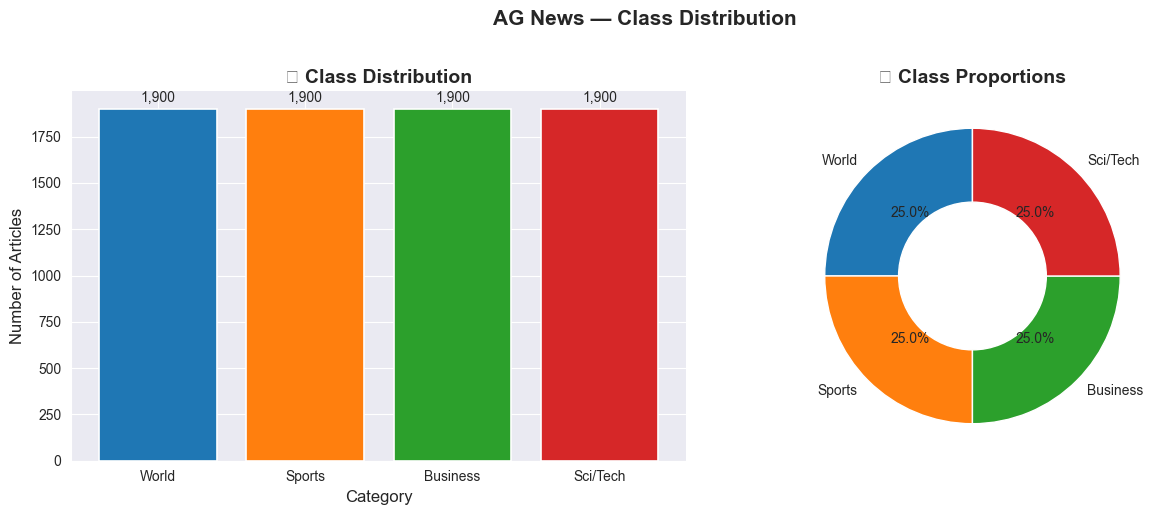

category  count
   World   1900
  Sports   1900
Business   1900
Sci/Tech   1900


In [5]:
# ── Normalise column names
df2 = df
for c in df.columns:
    df2 = df2.withColumnRenamed(c, c.strip().lower())

# ── Resolve label column
label_col_candidates = ['label', 'class', 'class index', 'class_index', 'category']
label_col = next((c for c in label_col_candidates if c in df2.columns), None)
if label_col is None:
    raise ValueError(f'Cannot find label column. Available: {df2.columns}')
print(f'✅  Using label column: "{label_col}"')

# ── Class distribution
class_dist_pd = (
    df2.groupBy(label_col).count()
    .orderBy(label_col)
    .toPandas()
)

class_names = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}
class_dist_pd['category'] = class_dist_pd[label_col].map(
    lambda x: class_names.get(int(x), str(x))
)

# ── Plot: Class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = sns.color_palette('tab10', len(class_dist_pd))
bars = axes[0].bar(
    class_dist_pd['category'], class_dist_pd['count'],
    color=colors, edgecolor='white', linewidth=1.2
)
axes[0].set_title('📊 Class Distribution', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Articles')
for bar, val in zip(bars, class_dist_pd['count']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{val:,}', ha='center', va='bottom', fontsize=10
    )

wedge_props = dict(width=0.5, edgecolor='white')
axes[1].pie(
    class_dist_pd['count'],
    labels=class_dist_pd['category'],
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops=wedge_props,
    startangle=90
)
axes[1].set_title('📈 Class Proportions', fontweight='bold')

plt.suptitle('AG News — Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(class_dist_pd[['category', 'count']].to_string(index=False))


---
## 🧹 Section 6 — Text Preprocessing & Label Engineering

### Steps performed
| Step | Operation | Reason |
|------|-----------|--------|
| 1 | Concatenate `title` + `description` | More signal for the classifier |
| 2 | Lowercase | Treats `The` and `the` as the same token |
| 3 | Remove non-alpha characters | Strips punctuation, numbers, HTML |
| 4 | Trim whitespace | Removes leading/trailing spaces |
| 5 | Binary label | Converts multi-class → binary (Class 1 = positive) |

> 💡 **Question:** Why might we want to remove numbers from news text? Can you think of a case where keeping them would be useful?


✅  Using text column(s): ('title', 'description')

── Binary Label Distribution ──────────────────────


               class  count
Negative (not World)   5700
    Positive (World)   1900


/var/folders/4j/r7bptkl550n4tzrjm9gz9yvh0000gn/T/ipykernel_24418/2039836349.py:55: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4j/r7bptkl550n4tzrjm9gz9yvh0000gn/T/ipykernel_24418/2039836349.py:55: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


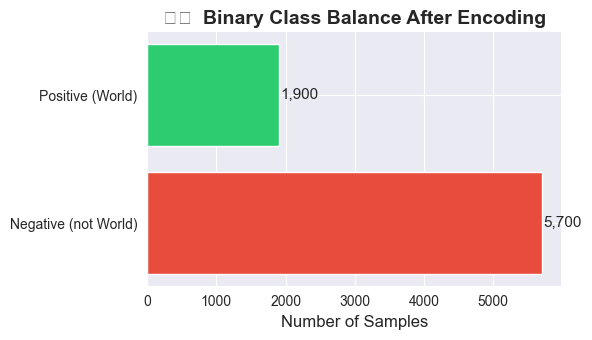


✅  Preprocessing complete.
+--------------------------------------------------------------------------------+-----+
|                                                                            text|label|
+--------------------------------------------------------------------------------+-----+
|fears for t n pension after talks unions representing workers at turner newal...|  0.0|
|the race is on second private team sets launch date for human spaceflight spa...|  0.0|
|ky company wins grant to study peptides ap ap a company founded by a chemistr...|  0.0|
|prediction unit helps forecast wildfires ap ap it s barely dawn when mike fit...|  0.0|
+--------------------------------------------------------------------------------+-----+
only showing top 4 rows


In [6]:
# ── Resolve text columns
text_candidates = [('title', 'description'), ('title',), ('text',), ('description',)]
text_cols = None
for cand in text_candidates:
    if all(x in df2.columns for x in cand):
        text_cols = cand
        break
if text_cols is None:
    raise ValueError(f'Cannot find text columns. Available: {df2.columns}')
print(f'✅  Using text column(s): {text_cols}')

# ── Combine title + description
if len(text_cols) == 2:
    df2 = df2.withColumn(
        'text_raw',
        concat_ws(' ', col(text_cols[0]).cast('string'), col(text_cols[1]).cast('string'))
    )
else:
    df2 = df2.withColumn('text_raw', col(text_cols[0]).cast('string'))

# ── Binary label
df2 = df2.withColumn('label_raw', col(label_col).cast('int'))
df2 = df2.withColumn('label', when(col('label_raw') == 1, lit(1.0)).otherwise(lit(0.0)))

# ── Text cleaning
df2 = (
    df2
    .withColumn('text', lower(col('text_raw')))
    .withColumn('text', regexp_replace(col('text'), r'[^a-z\s]', ' '))
    .withColumn('text', regexp_replace(col('text'), r'\s+', ' '))
    .withColumn('text', trim(col('text')))
    .select('text', 'label')
    .na.drop()
)

# ── Binary label distribution
print('\n── Binary Label Distribution ──────────────────────')
label_dist = df2.groupBy('label').count().orderBy('label').toPandas()
label_dist['class'] = label_dist['label'].map(
    {0.0: 'Negative (not World)', 1.0: 'Positive (World)'}
)
print(label_dist[['class', 'count']].to_string(index=False))

# ── Visualise binary class balance
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(
    label_dist['class'], label_dist['count'],
    color=['#e74c3c', '#2ecc71'], edgecolor='white'
)
for bar, val in zip(bars, label_dist['count']):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11)
ax.set_xlabel('Number of Samples')
ax.set_title('⚖️  Binary Class Balance After Encoding', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✅  Preprocessing complete.')
df2.show(4, truncate=80)


---
## ✂️ Section 7 — Train / Test Split

We hold out **20%** of the data as a test set.  
The `seed=42` ensures reproducibility.

> 🔎 **Best practice:** Always split *before* fitting any transformers to avoid **data leakage**.


📦  Train samples : 6,150  (80.9%)
🧪  Test  samples : 1,450  (19.1%)


/var/folders/4j/r7bptkl550n4tzrjm9gz9yvh0000gn/T/ipykernel_24418/154055949.py:15: UserWarning: Glyph 128256 (\N{TWISTED RIGHTWARDS ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128256 (\N{TWISTED RIGHTWARDS ARROWS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


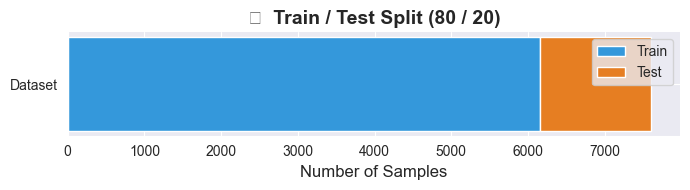

In [7]:
train_df, test_df = df2.randomSplit([0.8, 0.2], seed=42)

n_train = train_df.count()
n_test  = test_df.count()

print(f'📦  Train samples : {n_train:,}  ({n_train/(n_train+n_test)*100:.1f}%)')
print(f'🧪  Test  samples : {n_test:,}  ({n_test/(n_train+n_test)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 2))
ax.barh(['Dataset'], [n_train], color='#3498db', label='Train')
ax.barh(['Dataset'], [n_test],  left=[n_train], color='#e67e22', label='Test')
ax.set_xlabel('Number of Samples')
ax.set_title('🔀  Train / Test Split (80 / 20)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## 🔢 Section 8 — Feature Engineering: TF-IDF

### What is TF-IDF?

**Term Frequency – Inverse Document Frequency** transforms raw text into numerical feature vectors capturing how *important* each word is in a document relative to the corpus.

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{count of } t \text{ in } d}{|d|}}_\text{TF} \times \underbrace{\log\frac{N}{df(t)}}_\text{IDF}$$

### Pipeline Stages

```
Raw text
  ▼  Tokenizer          → ["world", "leaders", "meet", ...]
  ▼  StopWordsRemover   → removes "the", "is", "at" ...
  ▼  HashingTF          → sparse count vector (262,144 dims)
  ▼  IDF                → rescales by inverse document frequency
  ▼  Feature vector ready for a classifier
```

> 💡 **HashingTF** uses a hash function to map words to buckets — no vocabulary dictionary needed, which scales well to very large corpora.


In [8]:
# ── Define TF-IDF pipeline stages
tokenizer = Tokenizer(inputCol='text', outputCol='tokens')
stop_rm   = StopWordsRemover(inputCol='tokens', outputCol='filtered')
hash_tf   = HashingTF(inputCol='filtered', outputCol='tf', numFeatures=2**18)  # 262,144
idf       = IDF(inputCol='tf', outputCol='features')

# ── Fit on TRAINING DATA ONLY (prevents leakage)
featurizer = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf])
feat_model = featurizer.fit(train_df)

# ── Transform both splits
train_fe = feat_model.transform(train_df)
test_fe  = feat_model.transform(test_df)

print(f'✅  TF-IDF vectors created.')
print(f'    Feature dimensions: {hash_tf.getNumFeatures():,}')
print('\n── Sample feature vectors (sparse) ──────────────────────')
train_fe.select('text', 'features').show(3, truncate=60)


✅  TF-IDF vectors created.
    Feature dimensions: 262,144

── Sample feature vectors (sparse) ──────────────────────
+------------------------------------------------------------+------------------------------------------------------------+
|                                                        text|                                                    features|
+------------------------------------------------------------+------------------------------------------------------------+
|a better solution for israel the hysterical tone of danie...|(262144,[2480,13231,54001,54961,75758,75898,77003,87368,1...|
|a bit of wall st on the tigris the brokers and traders on...|(262144,[2731,9129,18697,38308,86311,89537,110006,116443,...|
|a canadian invasion a few weeks ago in a story on nortel ...|(262144,[28335,48982,51832,70162,70998,111767,113432,1309...|
+------------------------------------------------------------+------------------------------------------------------------+
only showing t

---
## 🤖 Section 9 — Model Training

| Model | Algorithm | Key Hyperparameter |
|-------|-----------|--------------------|
| Baseline | Logistic Regression | `maxIter=50` |
| Main | Linear SVM (LinearSVC) | `maxIter=50`, `regParam=0.1` |

### Why compare these two?
- **Logistic Regression** is the classic probabilistic baseline — outputs calibrated probabilities and is fast to train.
- **Linear SVM** maximises the *margin* between classes, which often works better on high-dimensional sparse text features.

> ⏱️ Training may take 1–3 minutes on Colab. This is expected.


In [9]:
# ── Define classifiers
lr  = LogisticRegression(featuresCol='features', labelCol='label', maxIter=50)
svm = LinearSVC(featuresCol='features', labelCol='label', maxIter=50, regParam=0.1)

# ── Logistic Regression
print('⏳  Training Logistic Regression baseline...')
t0 = time.time()
pipeline_lr = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf, lr])
lr_model    = pipeline_lr.fit(train_df)
lr_pred     = lr_model.transform(test_df)
lr_time     = time.time() - t0
print(f'   ✅  Done in {lr_time:.1f}s')

# ── Linear SVM
print('\n⏳  Training Linear SVM...')
t0 = time.time()
pipeline_svm = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf, svm])
svm_model    = pipeline_svm.fit(train_df)
svm_pred     = svm_model.transform(test_df)
svm_time     = time.time() - t0
print(f'   ✅  Done in {svm_time:.1f}s')


⏳  Training Logistic Regression baseline...


   ✅  Done in 4.6s

⏳  Training Linear SVM...
   ✅  Done in 10.1s


---
## 📊 Section 10 — Model Evaluation

### Metrics Explained

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Overall correctness |
| **F1 Score** | 2·(P·R)/(P+R) | Balance of precision & recall |
| **AUC-ROC** | Area under ROC curve | Separability (1.0 = perfect) |

> ⚠️ **Important:** On imbalanced datasets, accuracy alone is misleading. Always report F1 and AUC.



══════════════ Evaluation Results ══════════════

  Logistic Regression
    Accuracy : 0.9055
    F1 Score : 0.9061
    AUC-ROC  : 0.9449
    Train Time: 4.6s

  Linear SVM
    Accuracy : 0.9276
    F1 Score : 0.9272
    AUC-ROC  : 0.9600
    Train Time: 10.1s


/var/folders/4j/r7bptkl550n4tzrjm9gz9yvh0000gn/T/ipykernel_24418/4209236966.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


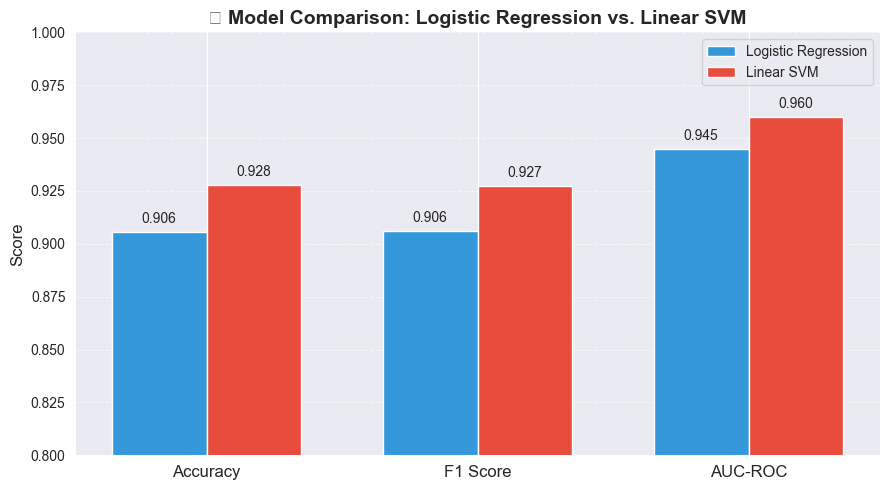

In [10]:
# ── Evaluators
acc_eval = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy'
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1'
)
auc_eval = BinaryClassificationEvaluator(
    labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)

lr_acc  = acc_eval.evaluate(lr_pred)
lr_f1   = f1_eval.evaluate(lr_pred)
lr_auc  = auc_eval.evaluate(lr_pred)

svm_acc = acc_eval.evaluate(svm_pred)
svm_f1  = f1_eval.evaluate(svm_pred)
svm_auc = auc_eval.evaluate(svm_pred)

# ── Results table
results = pd.DataFrame({
    'Model':         ['Logistic Regression', 'Linear SVM'],
    'Accuracy':      [lr_acc,  svm_acc],
    'F1 Score':      [lr_f1,   svm_f1],
    'AUC-ROC':       [lr_auc,  svm_auc],
    'Train Time (s)':[lr_time, svm_time]
})

print('\n══════════════ Evaluation Results ══════════════')
for _, row in results.iterrows():
    print(f"\n  {row['Model']}")
    print(f"    Accuracy : {row['Accuracy']:.4f}")
    print(f"    F1 Score : {row['F1 Score']:.4f}")
    print(f"    AUC-ROC  : {row['AUC-ROC']:.4f}")
    print(f"    Train Time: {row['Train Time (s)']:.1f}s")

# ── Bar chart comparison
metrics = ['Accuracy', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [lr_acc,  lr_f1,  lr_auc],  width, label='Logistic Regression', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, [svm_acc, svm_f1, svm_auc], width, label='Linear SVM',          color='#e74c3c', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=10
    )

ax.set_ylim(0.8, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score')
ax.set_title('📊 Model Comparison: Logistic Regression vs. Linear SVM', fontweight='bold')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


---
## 🧮 Section 11 — Confusion Matrix

```
              Predicted
              Neg   Pos
         ┌──────┬──────┐
  True   │  TN  │  FP  │   ← Negative class
  Pos    ├──────┼──────┤
         │  FN  │  TP  │   ← Positive class (World)
         └──────┴──────┘
```

- **TN**: Correctly classified as non-World
- **FP**: Non-World article wrongly classified as World
- **FN**: World article missed
- **TP**: Correctly classified as World


/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) Arial.
  fig.canvas.draw()
/var/folders/4j/r7bptkl550n4tzrjm9gz9yvh0000gn/T/ipykernel_24418/488229674.py:33: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) Arial.
  plt.tight_layout()
/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) Arial.
  fig.canvas.print

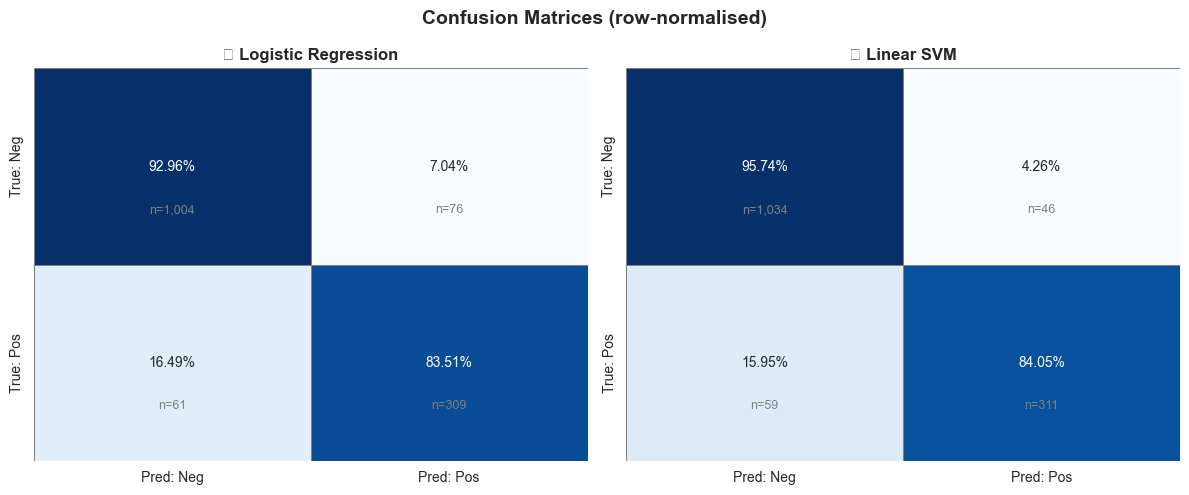


Logistic Regression — raw counts (TN  FP / FN  TP):
[[1004   76]
 [  61  309]]

Linear SVM — raw counts (TN  FP / FN  TP):
[[1034   46]
 [  59  311]]


In [11]:
def plot_confusion_matrix(pred_df, model_name, ax):
    rdd = pred_df.select('prediction', 'label').rdd.map(
        lambda r: (float(r[0]), float(r[1]))
    )
    cm_metrics = MulticlassMetrics(rdd)
    cm = cm_metrics.confusionMatrix().toArray()
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2%',
        cmap='Blues', ax=ax,
        xticklabels=['Pred: Neg', 'Pred: Pos'],
        yticklabels=['True: Neg', 'True: Pos'],
        linewidths=0.5, linecolor='grey',
        cbar=False
    )
    for i in range(2):
        for j in range(2):
            ax.text(
                j + 0.5, i + 0.72,
                f'n={int(cm[i,j]):,}',
                ha='center', va='center',
                fontsize=9, color='grey'
            )
    ax.set_title(f'🔲 {model_name}', fontweight='bold', fontsize=12)
    return cm

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_lr  = plot_confusion_matrix(lr_pred,  'Logistic Regression', axes[0])
cm_svm = plot_confusion_matrix(svm_pred, 'Linear SVM',          axes[1])

plt.suptitle('Confusion Matrices (row-normalised)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nLogistic Regression — raw counts (TN  FP / FN  TP):')
print(cm_lr.astype(int))
print('\nLinear SVM — raw counts (TN  FP / FN  TP):')
print(cm_svm.astype(int))


---
## 📈 Section 12 — ROC Curves

The **ROC (Receiver Operating Characteristic)** curve plots True Positive Rate vs False Positive Rate as the classification threshold varies.

- A **perfect classifier** follows the top-left corner (AUC = 1.0)
- A **random classifier** follows the diagonal (AUC = 0.5)
- **Higher AUC** → better discrimination between classes

> ⚠️ `LinearSVC` does not output calibrated probabilities. We use `rawPrediction` as the ranking score.


/var/folders/4j/r7bptkl550n4tzrjm9gz9yvh0000gn/T/ipykernel_24418/3142091933.py:39: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/Users/wizrdm/PycharmProjects/MLonBigData/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


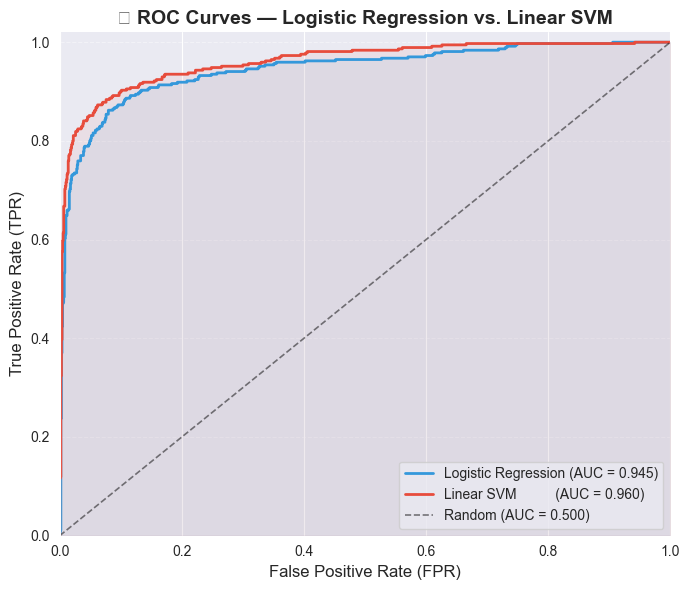

In [12]:
def compute_roc(pred_df, pos_class_idx=1):
    roc_pd = (
        pred_df.select('rawPrediction', 'label').rdd
        .map(lambda r: (float(r['rawPrediction'][pos_class_idx]), float(r['label'])))
        .toDF(['score', 'label'])
        .toPandas()
        .sort_values('score', ascending=False)
    )
    P  = (roc_pd['label'] == 1.0).sum()
    Nn = (roc_pd['label'] == 0.0).sum()
    tpr, fpr, tp, fp, prev = [], [], 0, 0, None
    for score, lab in zip(roc_pd['score'], roc_pd['label']):
        if prev is None or score != prev:
            tpr.append(tp / P if P else 0.0)
            fpr.append(fp / Nn if Nn else 0.0)
            prev = score
        if lab == 1.0: tp += 1
        else:          fp += 1
    tpr.append(1.0); fpr.append(1.0)
    return np.array(fpr), np.array(tpr)

fpr_lr,  tpr_lr  = compute_roc(lr_pred)
fpr_svm, tpr_svm = compute_roc(svm_pred)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_lr,  tpr_lr,  color='#3498db', lw=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
ax.plot(fpr_svm, tpr_svm, color='#e74c3c', lw=2, label=f'Linear SVM          (AUC = {svm_auc:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5, label='Random (AUC = 0.500)')

ax.fill_between(fpr_lr,  tpr_lr,  alpha=0.07, color='#3498db')
ax.fill_between(fpr_svm, tpr_svm, alpha=0.07, color='#e74c3c')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.set_title('📈 ROC Curves — Logistic Regression vs. Linear SVM', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


---
## 🧠 Section 13 — Reflection Questions

Answer the following in your lab report, using specific numbers from your output above.

### Conceptual
 **Why might Linear SVM outperform Logistic Regression** on high-dimensional sparse text features?

### Empirical (use your actual results)
**Compare the two models** on Accuracy, F1, and AUC. Which model would you recommend and why?
**Examine the confusion matrix.** Does the SVM make more False Positives or False Negatives? What is the real-world cost of each error type in a news classification system?


### Extension (optional)
**Try changing `regParam`** in LinearSVC (e.g., 0.01 or 1.0). How does this affect the AUC?



---
## 🧹 Section 14 — Cleanup

Always stop the Spark session when you are done to release resources.


In [13]:
spark.stop()
print('✅  Spark session stopped.')
print('\n🎉  Lab 6 complete! Remember to save this notebook and submit your lab report.')


✅  Spark session stopped.

🎉  Lab 6 complete! Remember to save this notebook and submit your lab report.


---

## 📚 Further Reading

- [PySpark MLlib Documentation](https://spark.apache.org/docs/latest/ml-guide.html)
- [Scikit-learn — Text Feature Extraction](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)
- [Understanding ROC Curves — Towards Data Science](https://towardsdatascience.com/understanding-auc-roc-curve-68b2303cc9c5)
- [AG News Dataset — Papers With Code](https://paperswithcode.com/dataset/ag-news)

---
*CN7030 — Big Data Technologies | Lab 9 | © Mustansar Ali Ghazanfar &
Module Teaching Team*
